## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"

In [2]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tools.eval_measures import rmse
import andes

andes.config_logger(stream_level=30)

In [3]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")
ss_ref = andes.load(case_path)

ss_ref.PFlow.run()

True

In [4]:
# TDS Constants
STEP_TIME = 0.01 # 10 ms

## Run TDS & Initial Results

In [8]:
ss = andes.load(case_path, setup=False)
ss.REGF2.set("Tr",1,0.005)
print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]


True

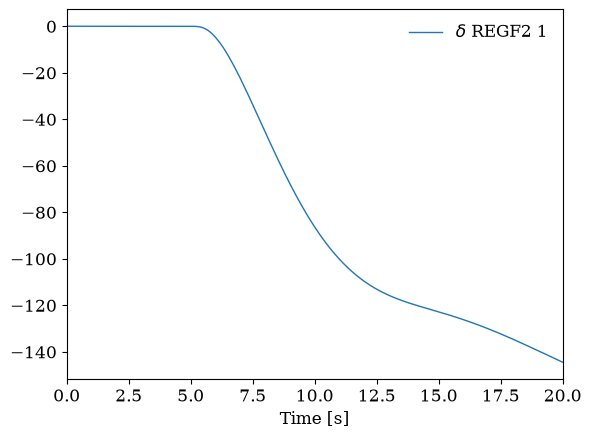

In [9]:
fig, ax = ss.TDS.plt.plot(ss.REGF2.delta)

## Metrics/Analysis

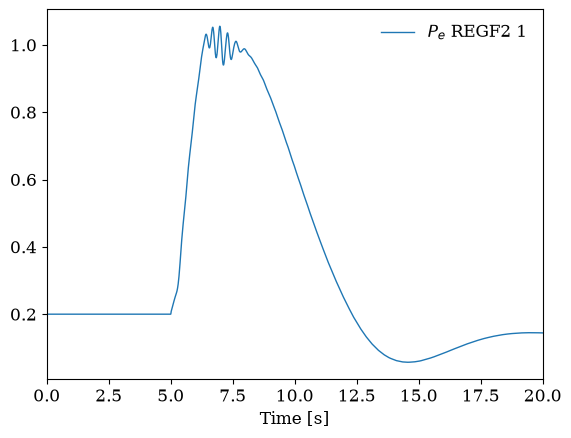

In [10]:
power_regf2_df = ss.TDS.get_timeseries(ss.REGF2.Pe)
fig, ax = ss.TDS.plt.plot(ss.REGF2.Pe)

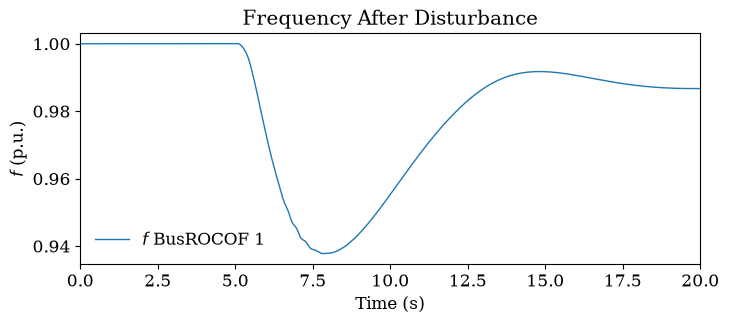

In [11]:
rocof_pu = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
fig, ax = ss.TDS.plt.plot(ss.BusROCOF.f, title="Frequency After Disturbance", xlabel="Time (s)", ylabel = f"$f$ (p.u.)", figsize=(8, 3))

In [12]:
run = 0

# conversion
S_n = ss.REGF2.get("Sn", 1)
f_0 = 60 #Hz

#
freq_timeseries = ss.TDS.get_timeseries(ss.BusROCOF.f).loc[:,"BusROCOF_1"]

peak_inertial_power = np.max(power_regf2_df) 
max_rocof = np.max(np.abs(rocof_pu))
freq_nadir = np.min(freq_timeseries)
tr = ss.REGF2.get("Tr", 1)

p_avail = ss.REGF2.get("Pmax", 1) # pu
p_ref = ss.PV.get("p0", 1) # pu

freq_nadir


np.float64(0.9377942418570264)

### H Calculation

In [13]:
deltaP = power_regf2_df.subtract(p_ref)
deltaF = freq_timeseries - 1

tds_df = pd.concat([deltaP, deltaF, rocof_pu], axis=1)
tds_df.columns = ["Delta P (pu)", "Delta F (pu)", "RoCoF (pu)"]

tds_df

,Delta P (pu),Delta F (pu),RoCoF (pu)
0.000000,0.000000e+00,0.000000,0.000000e+00
0.000100,0.000000e+00,0.000000,0.000000e+00
0.010100,3.406500e-09,0.000000,0.000000e+00
0.020100,4.100202e-09,0.000000,0.000000e+00
0.030100,2.661154e-09,0.000000,1.301203e-10
...,...,...,...
19.976867,-5.560016e-02,-0.013277,3.112929e-05
19.986867,-5.562744e-02,-0.013277,3.468417e-05
19.996867,-5.565569e-02,-0.013276,3.827858e-05
19.999900,-5.566433e-02,-0.013276,3.937365e-05


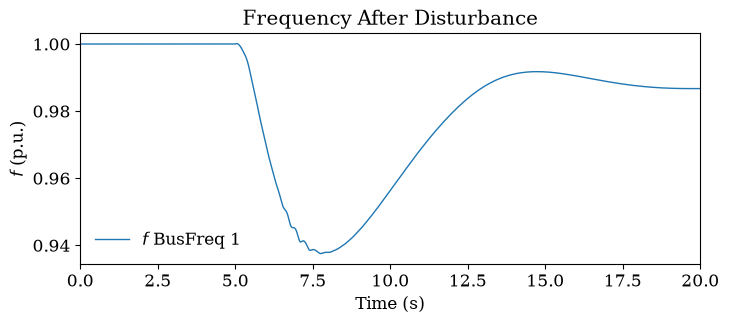

In [14]:
fig, ax = ss.TDS.plt.plot(ss.BusFreq.f, a=0,title="Frequency After Disturbance", xlabel="Time (s)", ylabel = f"$f$ (p.u.)", figsize=(8, 3))

In [16]:
window = 20 # Baruzzi et al. used 1 window = 20 steps = 200ms
time_invalid = 5 + window * STEP_TIME # will produce invalid results w/in the first window after disturbance
print(time_invalid)

X = sm.add_constant(tds_df[['RoCoF (pu)', 'Delta F (pu)']])  # add delta f as 2nd predictor
model = RollingOLS(tds_df['Delta P (pu)'], X, window=window)
res = model.fit()

H_t_raw = -res.params['RoCoF (pu)'] / 2 
D_t_raw = res.params['Delta F (pu)']

tds_df.loc[:,"H (s)"] = H_t_raw[time_invalid:]
tds_df.loc[:,"D"] = D_t_raw[time_invalid:]

#tds_df[1.1:1.3]

5.2


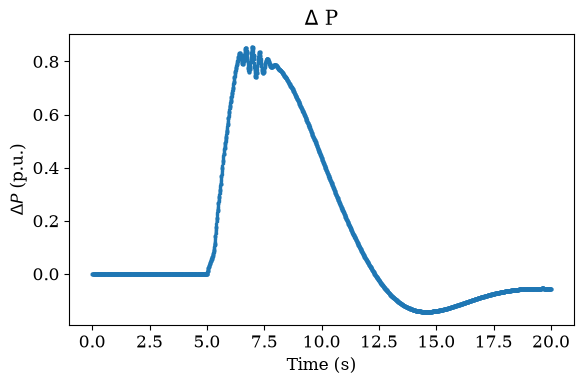

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"$\Delta$ P")
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"$\Delta P$ (p.u.)")

# plot actual
ax.plot(deltaP.index, deltaP, "s-", color="tab:blue",
        markersize=1.8)

plt.tight_layout()

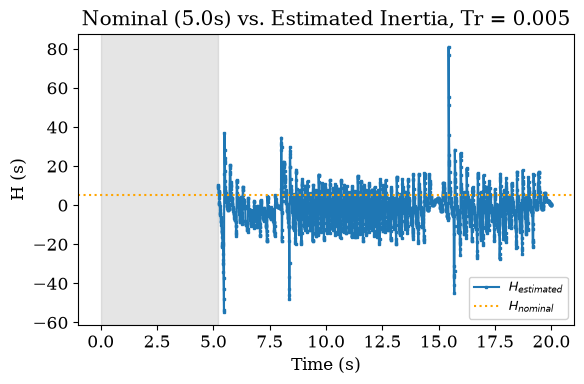

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1)
H_t = tds_df["H (s)"]

plot_title = f"Nominal ({H_gfm}s) vs. Estimated Inertia, Tr = {tr}"
ax.set_title(plot_title)
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (s)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue", markersize=1.8, label = f"$H_{{estimated}}$")

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label=f"$H_{{nominal}}$")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
#plt.xlim(0, 6)
#plt.ylim(-1, 12)
plt.tight_layout()

#plt.savefig(f'{out_dir}/1_testbench_figs/{plot_title}.png', dpi=300, bbox_inches='tight')

In [20]:
predicted = np.asarray(H_t[time_invalid:])
actual = np.full(predicted.size, H_gfm)
error = rmse(actual, predicted)
error

np.float64(11.522867564168333)

## Record Metrics

In [ ]:
# anything w/o units is in p.u. 
metrics_df = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[],
    "Settling Time (s)":[]
})
metrics_df

In [ ]:
def calc_settling_time(df, var, threshold=0.05):
    y = np.asarray(df.loc[:,var])
    t = df.index

    steady_state = np.average(y[-10:-1]) # average last 10 vals as steady-state
    allowed_error = threshold * abs(steady_state)
    
    error = np.abs(y - steady_state)
    
    # find all indices where the error exceeds the threshold
    outside_band_indices = np.where(error > allowed_error)[0]
    
    if len(outside_band_indices) == 0:
        return t[0] 
        
    last_outside_index = outside_band_indices[-1]
    
    # ensure we don't overflow the array boundary
    if last_outside_index < len(t) - 1:
        return t[last_outside_index + 1]
    else:
        return t[last_outside_index]

In [ ]:
settling_time = calc_settling_time(tds_df, "H (s)")
settling_time

In [ ]:
row = [tr, p_ref, peak_inertial_power, p_avail, error, max_rocof, freq_nadir, settling_time]
print(row)
metrics_df.loc[len(metrics_df)] = row
metrics_df